In [ ]:
# 한글 깨짐 방지
!pip install koreanize-matplotlib

In [ ]:
# 필요 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# csv 파일 불러오고 데이터 특성 확인
health_data = pd.read_csv("/content/smoking_health_data.csv")
health_data.columns = [c.strip() for c in health_data.columns]    # 컬럼명 앞뒤 공백 제거
health_data = health_data[["ID", "나이", "키(cm)", "몸무게(kg)", "BMI", "시력", "충치", "공복 혈당", "혈압", "중성 지방", "혈청 크레아티닌", "콜레스테롤", "고밀도지단백", "저밀도지단백", "헤모글로빈", "요 단백", "간 효소율", "label"]].copy()
health_data.columns = ["raw_id", "age", "height_cm", "weight_kg", "bmi", "sight", "cavity", "fasting_blood_sugar", "bp", "triglyceride", "creatinine", "cholesterol", "hdl", "ldl", "hemoglobin", "proteinuria", "liver_enzyme_level", "label"]

print(health_data.shape)    # (7000, 18)
print(health_data.info())
print(health_data.describe())    # 결측치 존재: 시력, 공복 혈당, 혈압, 중성 지방    # 도메인적 결측치(0이 아니어야 하는데 0인 경우) 없음  # 편차 큼: 저밀도지단백, 중성 지방, 시력

(7000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   raw_id               7000 non-null   object 
 1   age                  7000 non-null   int64  
 2   height_cm            7000 non-null   int64  
 3   weight_kg            7000 non-null   int64  
 4   bmi                  7000 non-null   float64
 5   sight                6860 non-null   float64
 6   cavity               7000 non-null   int64  
 7   fasting_blood_sugar  6860 non-null   float64
 8   bp                   6860 non-null   float64
 9   triglyceride         6860 non-null   float64
 10  creatinine           7000 non-null   float64
 11  cholesterol          7000 non-null   int64  
 12  hdl                  7000 non-null   int64  
 13  ldl                  7000 non-null   int64  
 14  hemoglobin           7000 non-null   float64
 15  proteinuria          7000 n

In [ ]:
# 범주형 데이터 확인
print("\n충치 범주: ")
display(health_data["cavity"].unique())

print("\n요 단백 범주: ")
display(health_data["proteinuria"].unique())


충치 범주: 


array([1, 0])


요 단백 범주: 


array([1, 3, 2, 4, 5])

In [ ]:
# 파생 변수 생성
health_data['Smoker'] = health_data['label'].replace({0: '비흡연자', 1: '흡연자'})

# 파생변수 변환 함수 파일 불러오기
import sys
sys.path.append("/content/feature_engineering.py")

from feature_engineering import add_features

# 파생변수 추가 확인
health_data = add_features(health_data)
health_data.head()

,raw_id,age,height_cm,weight_kg,bmi,sight,cavity,fasting_blood_sugar,bp,triglyceride,...,label,Smoker,age_section,bmi_level,fbs_level,triglyceride_level,hdl_criteria,ldl_criteria,cholesterol_check,creatinine_check
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,...,1,흡연자,30~50대,정상,정상,정상,심혈관보호효과,정상,경계,정상
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,...,0,비흡연자,30~50대,정상,당뇨병,정상,정상,높음,높음,정상
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,...,0,비흡연자,50~70대,저체중,정상,정상,정상,정상,정상,정상
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,...,0,비흡연자,30~50대,정상,정상,정상,심혈관보호효과,정상,정상,정상
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,...,0,비흡연자,50~70대,과체중,정상,정상,심혈관보호효과,경계,경계,정상


In [ ]:
# 시각화 파일 불러오기
sys.path.append("/content/viz.py")
from viz import boxplt_with_mean, hist_one_feature, all_feature_plot

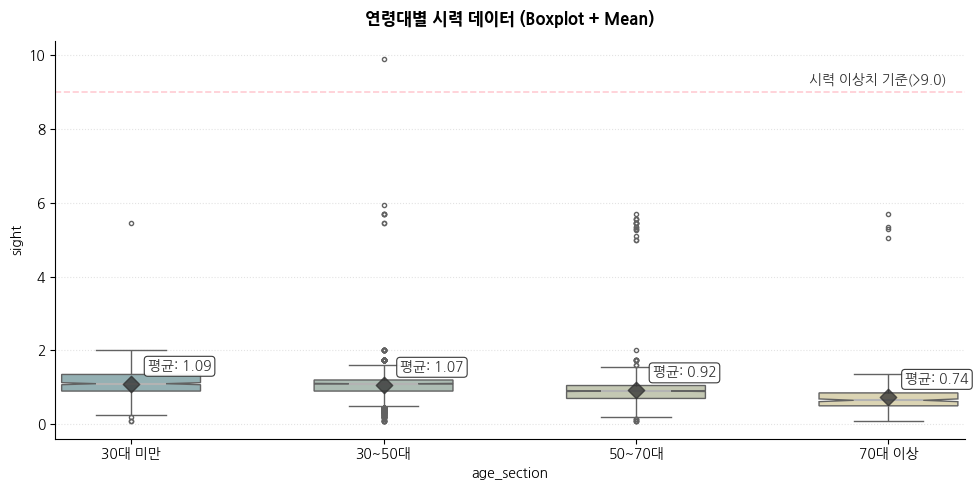

In [ ]:
# 시력 데이터 전처리1 - 데이터 분포 확인
order = ["30대 미만", "30~50대", "50~70대", "70대 이상"]

boxplt_with_mean(health_data, "age_section", "sight", order, "연령대별 시력 데이터", outlier_rule={"value": 9.0, "label": "시력 이상치 기준(>9.0)"})

In [ ]:
# 시력 데이터 전처리2 - “시력은 연령에 따라 구조적 차이가 존재하므로, 전체 최빈값 대체 대신 연령대별 평균값으로 결측치를 보완"
health_data["sight"] = (
    health_data
        .groupby("age_section")["sight"]
        .transform(lambda sight: sight.fillna(sight.mean()))
)

# 확인
health_data['sight'].isna().sum() # np.int64(0) -> 결측치 처리 완료

np.int64(0)

In [ ]:
# 시력 데이터 전처리3 - "아무리 눈이 좋은 몽골인이어도 9가 최대이기 때문에 9를 넘으면 이상치로 판단하고 이상치를 제외한 가장 높은 수치로 변환"
max_sight = health_data.loc[health_data["sight"] <= 9, "sight"].max()
health_data.loc[health_data["sight"] > 9, "sight"] = max_sight

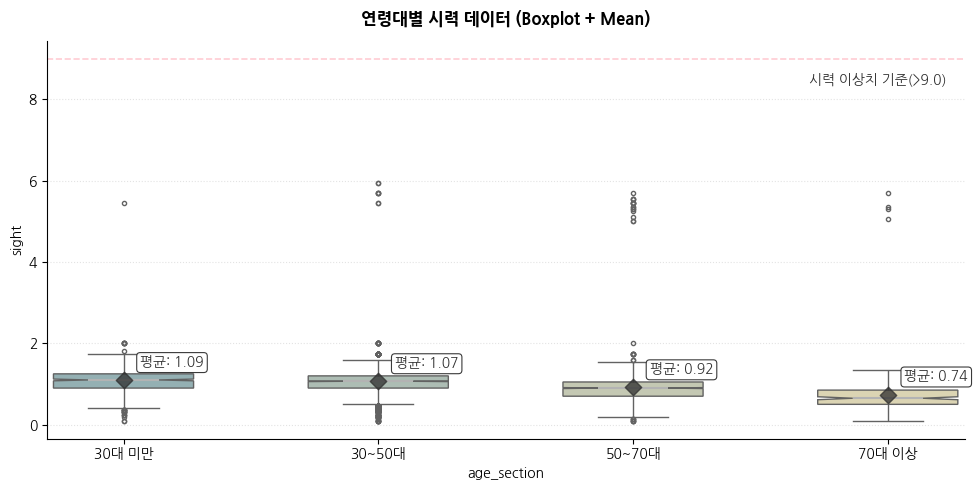

In [ ]:
# 시력 데이터 전처리4 - 전처리 결과 확인
order = ["30대 미만", "30~50대", "50~70대", "70대 이상"]

boxplt_with_mean(health_data, "age_section", "sight", order, "연령대별 시력 데이터", outlier_rule={"value": 9.0, "label": "시력 이상치 기준(>9.0)"})

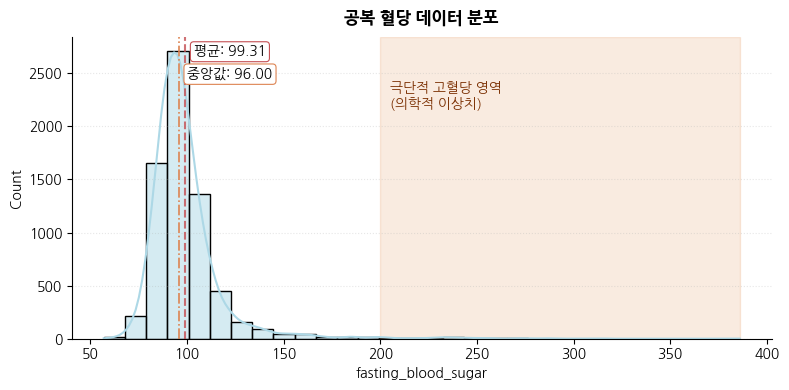

In [ ]:
# 공복 혈당 전처리1 - 분포 확인
hist_one_feature(health_data, "fasting_blood_sugar", "공복 혈당 데이터 분포", bins=30, upper=200)

In [ ]:
# 공복 혈당 전처리2 - 결측치 처리: "오른쪽으로 꼬리가 긴 치우친 분포이기 때문에 평균값보다 중앙값이 적절"
median_fbs = health_data["fasting_blood_sugar"].median()

health_data["fasting_blood_sugar"] = (
    health_data["fasting_blood_sugar"]
    .fillna(median_fbs)
)

health_data['sight'].isna().sum() # np.int64(0): 결측치 처리 완료

np.int64(0)

In [ ]:
# 공복 혈당 이상치 처리 - 정맥 혈당 검사의 일반적인 검출 범위: 통상적으로 10 mg/dL ~ 500 mg/dL 이상의 범위를 측정
# 실제 문제가 있는 의미 있는 데이터일 수 있으니 유지

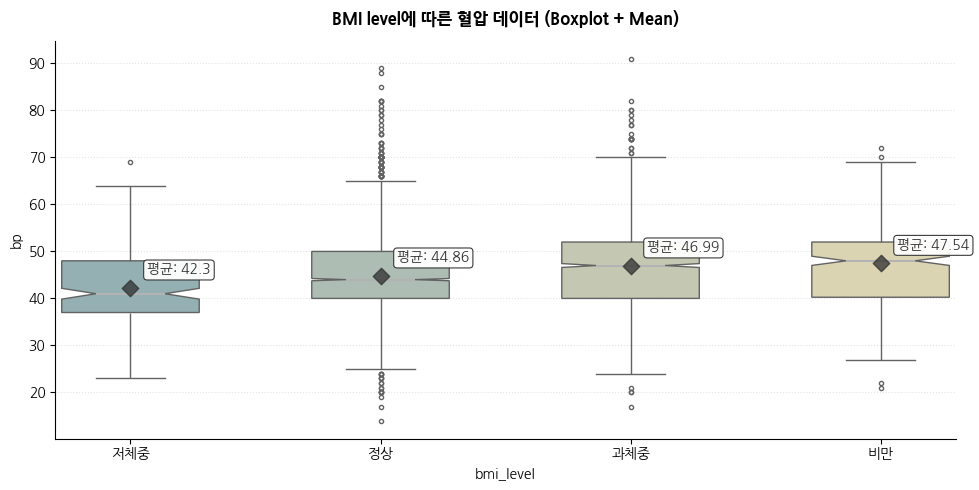

In [ ]:
# 혈압 전처리 1 - bmi에 따른 분포 확인
order = ["저체중", "정상", "과체중", "비만"]

boxplt_with_mean(health_data, "bmi_level", "bp", order, "BMI level에 따른 혈압 데이터")

In [ ]:
# 혈압 전처리2 - 결측치 처리: 이상치가 많아서 평균으로 대체하면 왜곡 가능. 중앙값으로 대체. 이상치는 의미 있는 데이터라 판단하여 유지.
health_data['bp'] = (
    health_data
        .groupby('bmi_level')['bp']
        .transform(lambda b: b.fillna(b.median()))
)
health_data['bp'].isna().sum() # np.int64(0): 결측치 처리 완료

np.int64(0)

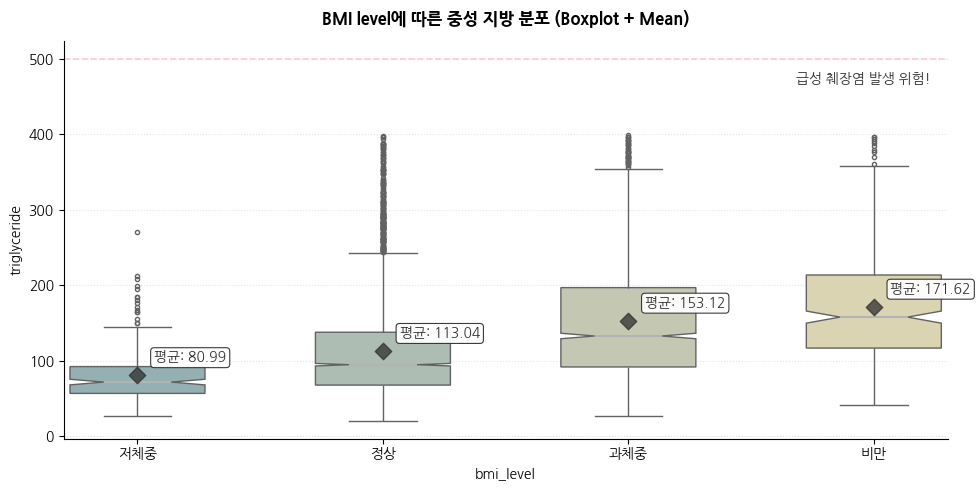

In [ ]:
# 중성 지방 전처리1 - bmi에 따른 분포 확인
order = ["저체중", "정상", "과체중", "비만"]

boxplt_with_mean(health_data, "bmi_level", "triglyceride", order, "BMI level에 따른 중성 지방 분포", outlier_rule={"value": 500, "label": "급성 췌장염 발생 위험!"})

In [ ]:
# 중성 지방 전처리2 - 결측치 처리: "그룹별 중앙값으로 대체"
health_data['triglyceride'] = (
    health_data
        .groupby('bmi_level')['triglyceride']
        .transform(lambda t: t.fillna(t.median()))
)
health_data['triglyceride'].isna().sum()

np.int64(0)

In [ ]:
# LDL 전처리 - 이상치 처리: "400을 초과하는 수치는 신뢰도가 떨어지기 때문에 400 이하의 데이터 값 중 가장 큰 값으로 대체"
max_ldl = health_data.loc[health_data["ldl"] <= 400, "ldl"].max()
health_data.loc[health_data["ldl"] > 400, "ldl"] = max_ldl

In [ ]:
health_data.isna().sum()

,0
raw_id,0
age,0
height_cm,0
weight_kg,0
bmi,0
sight,0
cavity,0
fasting_blood_sugar,0
bp,0
triglyceride,0


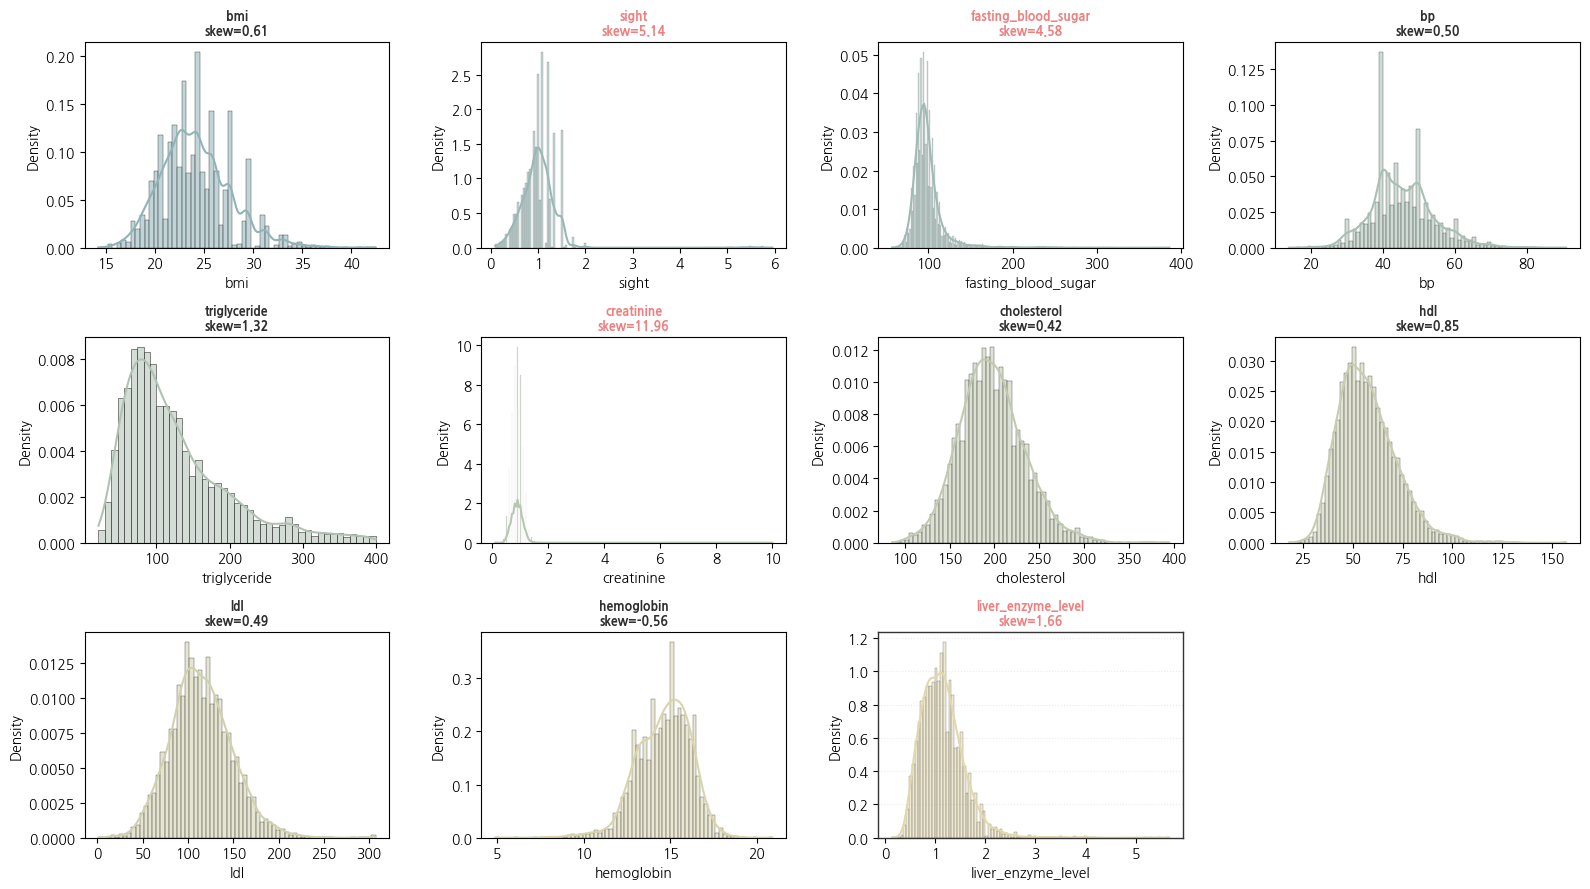

In [ ]:
# [전처리 step2] - 로그 변환 필요 유무 확인(왜도 파악)

feature_list = ["bmi", "sight", "fasting_blood_sugar", "bp", "triglyceride", "creatinine", "cholesterol", "hdl", "ldl", "hemoglobin", "liver_enzyme_level"]

all_feature_plot(health_data, feature_list)


In [ ]:
# 왜도 >= 1.5 feature들 로그변환
health_data["sight_log"] = np.log1p(health_data["sight"])
health_data["fbs_log"] = np.log1p(health_data["fasting_blood_sugar"])
health_data["creatinine_log"] = np.log1p(health_data["creatinine"])
health_data["lel_log"] = np.log1p(health_data["liver_enzyme_level"])

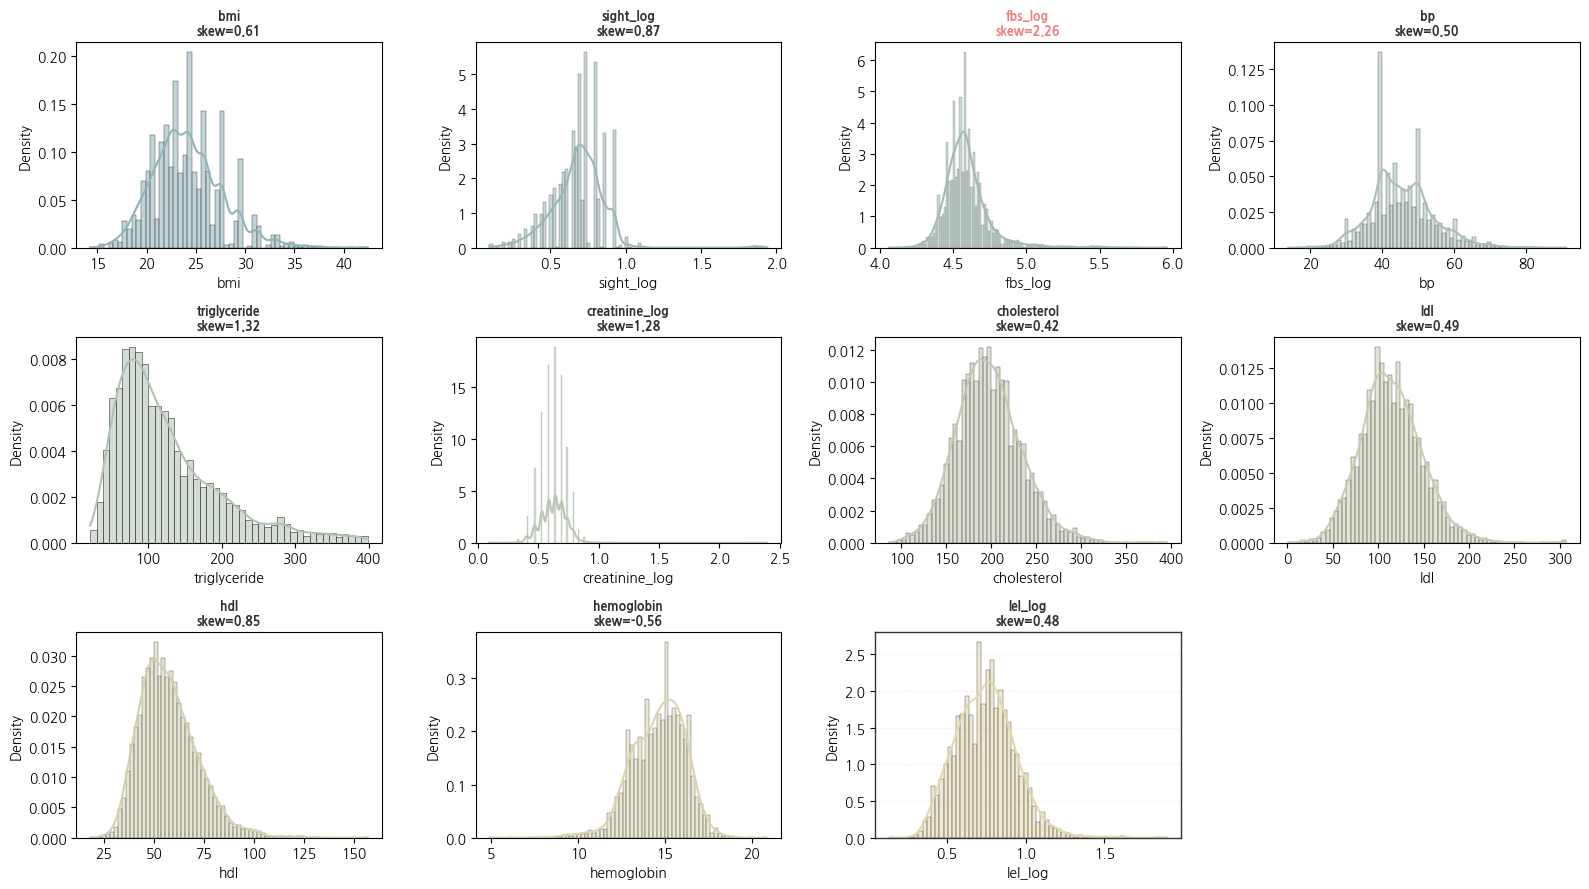

In [ ]:
# 로그 변환 후 확인
feature_list = ["bmi", "sight_log", "fbs_log", "bp", "triglyceride", "creatinine_log", "cholesterol", "ldl", "hdl", "hemoglobin", "lel_log"]

all_feature_plot(health_data, feature_list)

In [ ]:
# csv 파일 저장 전 마무리 체크
display(health_data.head(3))
print("\n전처리 후 info:")
health_data.info()

print("\n전처리 후 결측치 점검:")
print(health_data.isna().sum())

print("\n전처리 후 describe:")
health_data.describe()

,raw_id,age,height_cm,weight_kg,bmi,sight,cavity,fasting_blood_sugar,bp,triglyceride,...,fbs_level,triglyceride_level,hdl_criteria,ldl_criteria,cholesterol_check,creatinine_check,sight_log,fbs_log,creatinine_log,lel_log
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,...,정상,정상,심혈관보호효과,정상,경계,정상,0.741937,4.595120,0.832909,0.928219
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,...,당뇨병,정상,정상,높음,높음,정상,0.693147,5.159055,0.470004,0.896088
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,...,정상,정상,정상,정상,정상,정상,0.559616,4.574711,0.587787,0.712950



전처리 후 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   raw_id               7000 non-null   object 
 1   age                  7000 non-null   int64  
 2   height_cm            7000 non-null   int64  
 3   weight_kg            7000 non-null   int64  
 4   bmi                  7000 non-null   float64
 5   sight                7000 non-null   float64
 6   cavity               7000 non-null   int64  
 7   fasting_blood_sugar  7000 non-null   float64
 8   bp                   7000 non-null   float64
 9   triglyceride         7000 non-null   float64
 10  creatinine           7000 non-null   float64
 11  cholesterol          7000 non-null   int64  
 12  hdl                  7000 non-null   int64  
 13  ldl                  7000 non-null   int64  
 14  hemoglobin           7000 non-null   float64
 15  proteinuria          7000

,age,height_cm,weight_kg,bmi,sight,cavity,fasting_blood_sugar,bp,triglyceride,creatinine,...,hdl,ldl,hemoglobin,proteinuria,liver_enzyme_level,label,sight_log,fbs_log,creatinine_log,lel_log
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,...,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.010834,0.227429,99.241143,45.542429,126.648429,0.884900,...,57.355429,114.847571,14.631914,1.083857,1.144696,0.367286,0.682359,4.592130,0.627803,0.744641
std,12.063793,9.170213,12.978702,3.501945,0.416738,0.419202,20.982167,8.746313,72.594177,0.241523,...,14.506945,34.075206,1.540907,0.392051,0.432735,0.482100,0.173399,0.163921,0.106449,0.188434
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,...,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000,0.095310,4.060443,0.095310,0.131028
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,...,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000,0.587787,4.499810,0.587787,0.609766
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,106.000000,0.900000,...,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000,0.693147,4.574711,0.641854,0.741937
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,103.000000,50.000000,160.000000,1.000000,...,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000,0.788457,4.644391,0.693147,0.867100
max,85.000000,190.000000,130.000000,42.450000,5.950000,1.000000,386.000000,91.000000,399.000000,10.000000,...,157.000000,307.000000,20.900000,5.000000,5.670000,1.000000,1.938742,5.958425,2.397895,1.897620


In [ ]:
# csv 파일 저장
health_data.to_csv("smoking_health_data_preprocessed_v1.csv", index=False, encoding="utf-8")